<a href="https://colab.research.google.com/github/Castlebin/d2l-zh-pytorch-colab/blob/my_master/9_d2l-zh-pytorch-colab-reorg/03_%E7%BA%BF%E6%80%A7%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/01_%E7%BA%BF%E6%80%A7%E5%9B%9E%E5%BD%92.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 线性回归

本 notebook 完整介绍线性回归:
- 线性回归的基本概念和数学原理
- 从零开始实现线性回归
- 使用 PyTorch 的简洁实现

线性回归是最简单但也最重要的机器学习算法,是理解深度学习的第一步。

## 第一部分: 线性回归基础理论

### 1.1 什么是回归?

**回归(Regression)** 是建模自变量与因变量关系的方法。主要用于预测数值型输出。

**常见应用**:
- 预测房价(根据面积、位置等)
- 预测股票价格
- 预测销售量
- 预测住院时间

### 1.2 线性回归模型

**核心假设**: 输出与输入之间存在线性关系

**单特征线性模型**:
$$y = wx + b$$

**多特征线性模型**:
$$y = w_1x_1 + w_2x_2 + ... + w_dx_d + b$$

或用向量形式表示:
$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

其中:
- $\mathbf{x}$: 输入特征向量
- $\mathbf{w}$: 权重向量
- $b$: 偏置(截距)
- $\hat{y}$: 预测值

### 1.3 损失函数

我们需要衡量预测值与真实值的差距。**均方误差(MSE)**是最常用的损失函数:

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}^{(i)} - y^{(i)})^2$$

**目标**: 找到最优的$\mathbf{w}$和$b$,使损失函数最小化

### 1.4 优化算法 - 小批量随机梯度下降(Mini-batch SGD)

**梯度下降更新规则**:
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial L}{\partial \mathbf{w}}$$
$$b \leftarrow b - \eta \frac{\partial L}{\partial b}$$

其中$\eta$是学习率(learning rate)

---

## 第二部分: 从零开始实现线性回归

我们将手动实现线性回归的所有组件,以深入理解其工作原理。

In [1]:
# 让 matplotlib 绘图可以直接支持中文，安装一下下面这个包
!pip install -U matplotlib_cn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 63.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for matplotlib_cn: filename=matplotlib_cn-1.0.4-py3-none-any.whl size=5294725 sha256=c9a071e0964e8f2f0f7e17e30270a9df865c18e9b29a56fa164902a0341fe79e
  Stored in directory: /root/.cache/pip/wheels/96/8c/13/e82ae20295b23f53bea146b7e8f15dc39df68ef136502e8033
Successfully built matplotlib_cn


In [2]:
# 让 matplotlib 绘图支持中文
from matplotlib_cn import matplotlib_chinese

matplotlib_chinese.enable_matplotlib_chinese()

[matplotlib_cn] matplotlib enabled with Chinese font: SimHei 


In [3]:
import random
import torch
import matplotlib.pyplot as plt
import numpy as np

### 2.1 生成数据集

我们生成一个人造数据集,真实模型为: $y = 2x_1 - 3.4x_2 + 4.2 + \epsilon$

In [4]:
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)  # 添加噪声
    return X, y.reshape((-1, 1))

# 真实参数
true_w = torch.tensor([2, -3.4])
true_b = 4.2

# 生成1000个样本
features, labels = synthetic_data(true_w, true_b, 1000)

print('特征形状:', features.shape)
print('标签形状:', labels.shape)
print('\n第一个样本:')
print('特征:', features[0])
print('标签:', labels[0])

特征形状: torch.Size([1000, 2])
标签形状: torch.Size([1000, 1])

第一个样本:
特征: tensor([0.5786, 0.2312])
标签: tensor([4.5577])


**可视化数据**

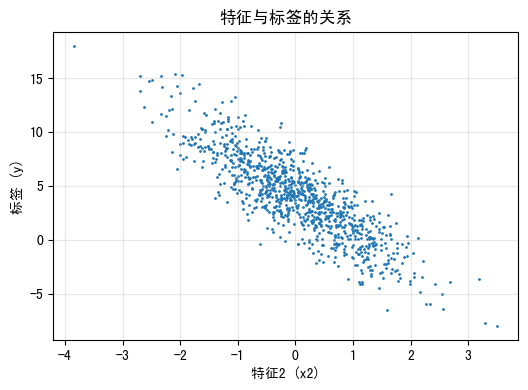

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(features[:, 1].numpy(), labels.numpy(), s=1)
plt.xlabel('特征2 (x2)')
plt.ylabel('标签 (y)')
plt.title('特征与标签的关系')
plt.grid(True, alpha=0.3)
plt.show()

### 2.2 读取数据集 - 小批量迭代器

In [6]:
def data_iter(batch_size, features, labels):
    """生成小批量数据"""
    num_examples = len(features)
    indices = list(range(num_examples))
    # 随机打乱样本
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# 测试数据迭代器
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print('批量特征形状:', X.shape)
    print('批量标签形状:', y.shape)
    print('\n第一个批量的前3个样本:')
    print(X[:3])
    print(y[:3])
    break

批量特征形状: torch.Size([10, 2])
批量标签形状: torch.Size([10, 1])

第一个批量的前3个样本:
tensor([[-1.3503, -0.1292],
        [-0.4041, -0.8490],
        [-0.2939,  0.2726]])
tensor([[1.9315],
        [6.2853],
        [2.6847]])


### 2.3 初始化模型参数

In [7]:
# 初始化权重和偏置
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

print('初始权重:', w.T)
print('初始偏置:', b)

初始权重: tensor([[-0.0006,  0.0019]], grad_fn=<PermuteBackward0>)
初始偏置: tensor([0.], requires_grad=True)


### 2.4 定义模型

In [8]:
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

### 2.5 定义损失函数

In [9]:
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

### 2.6 定义优化算法

In [10]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 2.7 训练模型

In [11]:
# 超参数
lr = 0.03  # 学习率
num_epochs = 3  # 训练轮数
batch_size = 10

# 训练网络
net = linreg
loss = squared_loss

# 记录损失用于绘图
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    num_batches = 0

    for X, y in data_iter(batch_size, features, labels):
        # 前向传播
        l = loss(net(X, w, b), y)

        # 反向传播
        l.sum().backward()

        # 更新参数
        sgd([w, b], lr, batch_size)

        epoch_loss += l.sum().item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f'epoch {epoch + 1}, 平均损失: {avg_loss:.4f}')

print('\n训练完成!')
print(f'真实权重: {true_w}')
print(f'学到的权重: {w.reshape(true_w.shape)}')
print(f'\n真实偏置: {true_b}')
print(f'学到的偏置: {b}')

epoch 1, 平均损失: 28.1836
epoch 2, 平均损失: 0.0959
epoch 3, 平均损失: 0.0008

训练完成!
真实权重: tensor([ 2.0000, -3.4000])
学到的权重: tensor([ 1.9987, -3.3993], grad_fn=<ViewBackward0>)

真实偏置: 4.2
学到的偏置: tensor([4.1989], requires_grad=True)


**可视化训练过程**

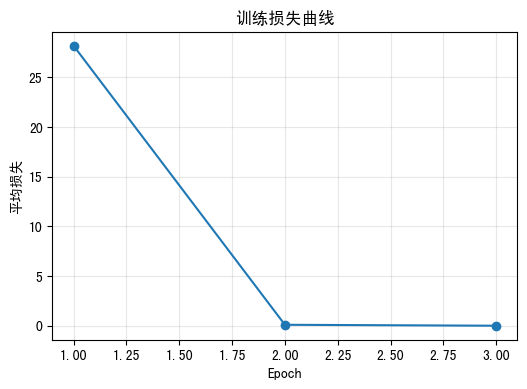

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('平均损失')
plt.title('训练损失曲线')
plt.grid(True, alpha=0.3)
plt.show()

---

## 第三部分: 使用PyTorch的简洁实现

从零实现帮助我们理解原理,但实际应用中我们使用PyTorch提供的高级API。

In [13]:
import torch
from torch import nn
from torch.utils import data

### 3.1 生成数据集(复用之前的数据)

In [14]:
# 使用相同的数据
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('数据集准备完成')
print('特征形状:', features.shape)
print('标签形状:', labels.shape)

数据集准备完成
特征形状: torch.Size([1000, 2])
标签形状: torch.Size([1000, 1])


### 3.2 使用PyTorch的数据迭代器

In [15]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

# 测试
print('使用PyTorch DataLoader:')
for X, y in data_iter:
    print('批量形状:', X.shape, y.shape)
    break

使用PyTorch DataLoader:
批量形状: torch.Size([10, 2]) torch.Size([10, 1])


### 3.3 定义模型

使用`nn.Sequential`构建模型,`nn.Linear`是全连接层。

In [16]:
# 定义模型
net = nn.Sequential(nn.Linear(2, 1))

print('模型结构:')
print(net)

模型结构:
Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
)


### 3.4 初始化模型参数

In [17]:
# 访问第一层(索引0),然后访问权重和偏置
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

print('初始化后的参数:')
print('权重:', net[0].weight.data)
print('偏置:', net[0].bias.data)

初始化后的参数:
权重: tensor([[ 0.0012, -0.0090]])
偏置: tensor([0.])


### 3.5 定义损失函数

In [18]:
# MSELoss计算均方误差(默认求平均)
loss = nn.MSELoss()

print('损失函数:', loss)

损失函数: MSELoss()


### 3.6 定义优化算法

In [19]:
# SGD优化器
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

print('优化器:', trainer)

优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.03
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### 3.7 训练模型

In [20]:
num_epochs = 3
losses_concise = []

for epoch in range(num_epochs):
    epoch_loss = 0
    num_batches = 0

    for X, y in data_iter:
        # 前向传播
        l = loss(net(X), y)

        # 反向传播
        trainer.zero_grad()  # 梯度清零
        l.backward()  # 计算梯度
        trainer.step()  # 更新参数

        epoch_loss += l.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses_concise.append(avg_loss)
    print(f'epoch {epoch + 1}, 平均损失: {avg_loss:.6f}')

print('\n训练完成!')
print(f'真实权重: {true_w}')
print(f'学到的权重: {net[0].weight.data.reshape(true_w.shape)}')
print(f'\n真实偏置: {true_b}')
print(f'学到的偏置: {net[0].bias.data}')

epoch 1, 平均损失: 2.876471
epoch 2, 平均损失: 0.000115
epoch 3, 平均损失: 0.000103

训练完成!
真实权重: tensor([ 2.0000, -3.4000])
学到的权重: tensor([ 2.0004, -3.3989])

真实偏置: 4.2
学到的偏置: tensor([4.2008])


**对比两种实现的训练效果**

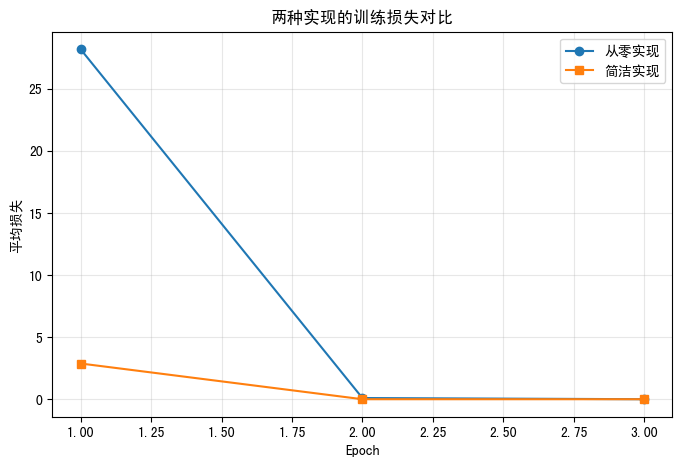

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', label='从零实现')
plt.plot(range(1, num_epochs + 1), losses_concise, marker='s', label='简洁实现')
plt.xlabel('Epoch')
plt.ylabel('平均损失')
plt.title('两种实现的训练损失对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.8 使用模型进行预测

In [22]:
# 创建一些测试数据
test_features = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

# 预测
with torch.no_grad():
    predictions = net(test_features)

print('测试特征:')
print(test_features)
print('\n预测结果:')
print(predictions)

# 用真实参数计算
true_predictions = torch.matmul(test_features, true_w.reshape(-1, 1)) + true_b
print('\n真实值(用真实参数计算):')
print(true_predictions)

测试特征:
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])

预测结果:
tensor([[-0.5966],
        [-3.3937],
        [-6.1908]])

真实值(用真实参数计算):
tensor([[-0.6000],
        [-3.4000],
        [-6.2000]])


---

## 小结

### 从零实现 vs 简洁实现

| 组件 | 从零实现 | 简洁实现 |
|------|----------|----------|
| 数据迭代器 | 手动实现 | `DataLoader` |
| 模型 | 手动函数 | `nn.Sequential` + `nn.Linear` |
| 损失函数 | 手动实现 | `nn.MSELoss` |
| 优化器 | 手动SGD | `torch.optim.SGD` |
| 训练循环 | 手动梯度更新 | `backward()` + `step()` |

### 关键要点

1. **线性回归模型**: $\hat{y} = \mathbf{w}^\top \mathbf{x} + b$
2. **损失函数**: 均方误差 $L = \frac{1}{n}\sum(\hat{y} - y)^2$
3. **优化算法**: 小批量随机梯度下降
4. **训练流程**:
   - 前向传播 → 计算损失
   - 反向传播 → 计算梯度
   - 参数更新 → 减小损失

### PyTorch核心组件

- `nn.Module`: 所有神经网络模块的基类
- `nn.Linear`: 全连接层
- `nn.MSELoss`: 均方误差损失
- `torch.optim.SGD`: 随机梯度下降优化器
- `DataLoader`: 高效的数据加载器

## 练习

1. **修改学习率**: 尝试不同的学习率(0.001, 0.01, 0.1, 1.0),观察训练效果
2. **改变批量大小**: 测试batch_size为1, 10, 100时的训练速度和效果
3. **添加特征**: 修改数据生成函数,使用3个或更多特征
4. **可视化拟合**: 绘制真实函数和学到的函数的对比图
5. **实现其他优化器**: 尝试实现momentum或Adam优化器
6. **正则化**: 添加L2正则化(权重衰减)到损失函数中
7. **交叉验证**: 将数据分为训练集和测试集,评估泛化性能